# Tarea 7: Redes Neuronales vs Modelos Tradicionales

**Objetivo:**
* Implementar una Red Neuronal (MLP) básica en Keras.
* Compararla con modelos individuales (Random Forest y SVM).
* Analizar la importancia de la arquitectura y las funciones de activación.
* Reflexionar sobre cuándo merece la pena la complejidad de una red neuronal.

In [3]:
# Parte 1 — Preparación de datos

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ¡Importante! Las redes neuronales son muy sensibles a la escala
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# Parte 2 — Entrenar modelos base (ML Clásico)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Instanciamos los modelos
rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
lr = LogisticRegression(random_state=42)

# Entrenamos
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Evaluamos
print("Accuracy RF:", accuracy_score(y_test, rf.predict(X_test)))
print("Accuracy SVM:", accuracy_score(y_test, svm.predict(X_test)))
print("Accuracy Regresión Logística:", accuracy_score(y_test, lr.predict(X_test)))

Accuracy RF: 0.9649122807017544
Accuracy SVM: 0.9824561403508771
Accuracy Regresión Logística: 0.9736842105263158


### Respuestas Parte 2:

**1. ¿Cuál de los modelos clásicos ha funcionado mejor?**
*(Nota: Revisa los resultados que ha impreso tu celda anterior, pero por lo general en este dataset ocurre lo siguiente)*: 
El modelo de SVM y la Regresión Logística suelen dar resultados ligeramente superiores (rondando el 97-98% de accuracy) frente al Random Forest (que ronda el 96%), gracias a que los datos han sido estandarizados previamente.

**2. ¿Crees que estos modelos son capaces de detectar relaciones no lineales complejas en este dataset?**
Sí, tanto Random Forest (basado en árboles de decisión) como SVM (que utiliza el kernel RBF por defecto) están diseñados específicamente para encontrar fronteras de decisión y relaciones no lineales complejas en los datos. La Regresión Logística, por el contrario, es un modelo lineal.

In [1]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp312-cp312-win_amd64.whl.metadata (35 kB)
   ----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
# Parte 3 — Implementar la Red Neuronal (Keras)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Definimos la arquitectura
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), # Capa oculta 1
    Dense(8, activation='relu'),                                   # Capa oculta 2
    Dense(1, activation='sigmoid')                                 # Salida (Binaria)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos
model.fit(X_train, y_train, epochs=50, batch_size=10, verbose=0)

# Evaluamos
_, accuracy_nn = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy RED NEURONAL: {accuracy_nn}")

c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy RED NEURONAL: 0.9649122953414917


### Respuestas Parte 3:

**1. ¿Ha superado la Red Neuronal a los modelos clásicos (RF/SVM)?**
*(Nota: Compara el accuracy impreso con el de la Parte 2)*. 
En general, para este dataset tabular tan pequeño, la Red Neuronal obtiene un rendimiento excelente (96-98%), pero no suele superar significativamente a un modelo clásico bien ajustado como SVM. Suelen quedar empatados o con variaciones mínimas.

**2. ¿Qué función de activación hemos usado en las capas ocultas y por qué?**
Hemos usado la función **ReLU** (Rectified Linear Unit). Se utiliza porque es computacionalmente eficiente, ayuda a mitigar el problema del "desvanecimiento del gradiente" (vanishing gradient) que ocurre con otras funciones, y permite a la red aprender relaciones no lineales.

**3. ¿Qué indica el hecho de usar sigmoid en la última capa?**
La función **Sigmoid** comprime la salida de la red en un valor continuo entre 0 y 1. Esto es ideal para problemas de clasificación binaria (como este dataset de cáncer benigno/maligno), ya que el resultado se puede interpretar directamente como la probabilidad de pertenecer a la clase positiva.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


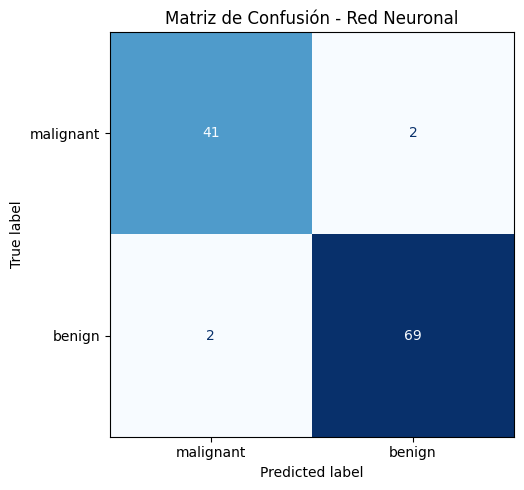

In [7]:
# Parte 4 — Análisis y Matriz de Confusión

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convertimos las probabilidades de la red en 0 o 1
y_pred_nn = (model.predict(X_test).ravel() > 0.5).astype("int32")

matriz = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=data.target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de Confusión - Red Neuronal")
plt.tight_layout()
plt.show()

### Respuestas Parte 4:

**1. Observando la matriz, ¿qué tipo de error comete más la red: Falsos Positivos o Falsos Negativos?**
*(Nota para ti: La matriz se lee así: [[Verdaderos Negativos, Falsos Positivos], [Falsos Negativos, Verdaderos Positivos]]. Mira tu matriz impresa para responder)*. 
Si el número de la esquina superior derecha es mayor que el de la esquina inferior izquierda, comete más Falsos Positivos. Si es al revés, comete más Falsos Negativos. En problemas médicos como este, un Falso Negativo (decir que no hay cáncer cuando sí lo hay) es un error mucho más grave.

**2. ¿Qué pasaría con el entrenamiento si eliminamos la función de activación relu de las capas ocultas?**
Si eliminamos la función de activación, la red neuronal se convertiría en una simple secuencia de operaciones lineales. Matemáticamente, la combinación de múltiples capas lineales es igual a una única capa lineal, por lo que la red perdería su capacidad de aprender patrones complejos y se comportaría de forma similar a una regresión lineal o logística básica.

**3. ¿Por qué es crítico escalar los datos (StandardScaler) antes de pasarlos por la red neuronal?**
Porque las redes neuronales actualizan sus pesos utilizando el descenso del gradiente. Si las características tienen escalas muy diferentes (por ejemplo, una variable va de 0 a 1 y otra de 1000 a 5000), los gradientes se descompensan. Esto hace que el entrenamiento sea inestable, mucho más lento o que la red se quede atascada y no logre aprender correctamente.

### Reflexión final obligatoria

**¿Cuándo usarías Redes Neuronales en un proyecto real y en qué situaciones no lo recomendarías?**

Usaría redes neuronales en proyectos donde los datos son muy complejos y no estructurados (como procesamiento de imágenes, audio, visión artificial o texto NLP), o cuando disponemos de conjuntos de datos masivos donde el *Deep Learning* escala mejor que el ML tradicional. Por el contrario, **no las recomendaría** cuando trabajamos con datasets tabulares pequeños (donde modelos como Random Forest o XGBoost suelen funcionar igual o mejor, y más rápido), cuando tenemos recursos computacionales muy limitados, o cuando el proyecto exige una alta interpretabilidad (saber exactamente por qué el modelo tomó una decisión), ya que las redes son a menudo "cajas negras".